# EDA — Kaggle Playground S6E5: F1 Pit-Stop Prediction

Visual companion to [src/eda.py](../src/eda.py) and [docs/eda.md](../docs/eda.md). Tables, schema dumps, and identity checks live in those files; this notebook focuses on **plots only**.

Sections:

1. Target distribution
2. Year × pit rates (the 2023 anomaly)
3. Compound breakdown
4. Race row counts
5. Numeric distributions & outliers
6. Train vs test overlap
7. Correlation heatmap
8. TyreLife (× Compound)
9. RaceProgress pit window
10. Position → target rate
11. *Engineered features* — field pit share, SC detection, undercut signals, normalized TyreLife (loaded from `data/train_features.parquet`; run `python src/features.py` to generate)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DATA = Path("..") / "data"
train = pl.read_csv(DATA / "train.csv")
test = pl.read_csv(DATA / "test.csv")

features_path = DATA / "train_features.parquet"
train_fe = pl.read_parquet(features_path) if features_path.exists() else None

print(f"train: {train.shape}  test: {test.shape}")
print(
    f"train_features: {train_fe.shape}"
    if train_fe is not None
    else "train_features.parquet not found — engineered-feature plots will be skipped"
)

train: (439140, 16)  test: (188165, 15)
train_features: (439140, 65)


## 1. Target distribution

~20% positives. AUC-evaluated, no resampling needed.

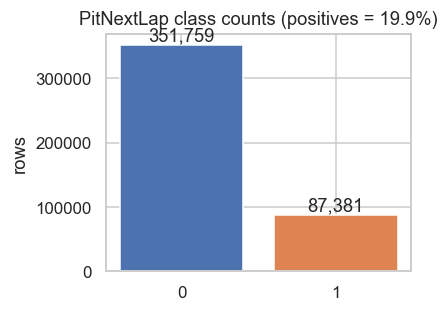

In [2]:
pos = int(train["PitNextLap"].sum())
neg = train.height - pos

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["0", "1"], [neg, pos], color=["#4c72b0", "#dd8452"])
ax.set_title(f"PitNextLap class counts (positives = {pos / train.height:.1%})")
ax.set_ylabel("rows")
for i, v in enumerate([neg, pos]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 2. Year × pit rates

2023 has the most rows yet a `PitStop` rate of 1.2% and `PitNextLap` rate of <1% — both collapse across **every** compound. Synthetic-data artefact, not a real strategy shift.

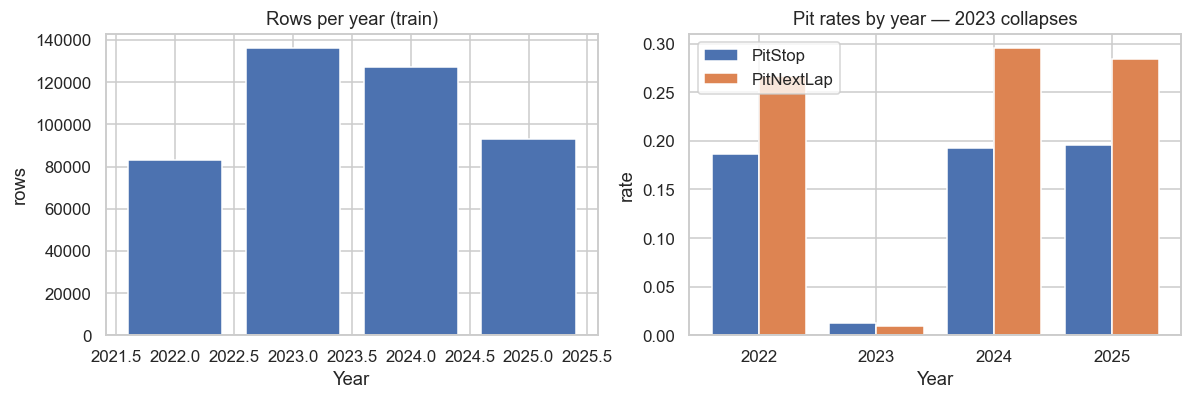

In [3]:
year_stats = (
    train.group_by("Year")
    .agg(
        pl.len().alias("n_rows"),
        pl.col("PitStop").mean().alias("PitStop_rate"),
        pl.col("PitNextLap").mean().alias("PitNextLap_rate"),
    )
    .sort("Year")
)

years = year_stats["Year"].to_list()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].bar(years, year_stats["n_rows"].to_list(), color="#4c72b0")
axes[0].set_title("Rows per year (train)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("rows")

w = 0.4
axes[1].bar([y - w / 2 for y in years], year_stats["PitStop_rate"].to_list(),
            label="PitStop", color="#4c72b0", width=w)
axes[1].bar([y + w / 2 for y in years], year_stats["PitNextLap_rate"].to_list(),
            label="PitNextLap", color="#dd8452", width=w)
axes[1].set_title("Pit rates by year — 2023 collapses")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("rate")
axes[1].set_xticks(years)
axes[1].legend()
plt.tight_layout()
plt.show()

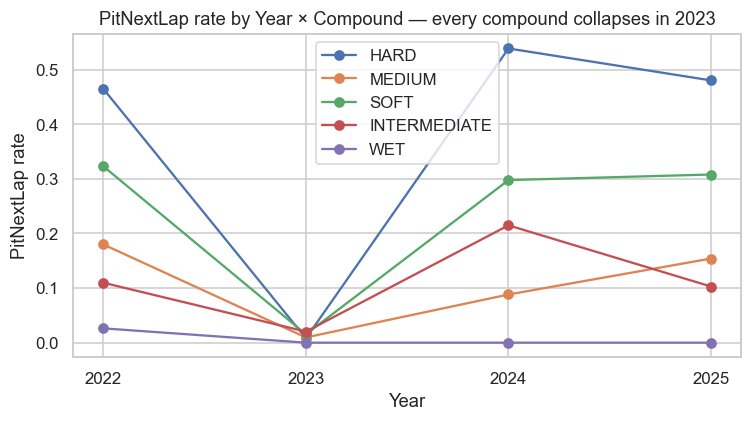

In [4]:
year_compound = (
    train.group_by(["Year", "Compound"])
    .agg(pl.col("PitNextLap").mean().alias("rate"), pl.len().alias("n"))
    .sort(["Year", "Compound"])
)

fig, ax = plt.subplots(figsize=(7, 4))
for comp in ["HARD", "MEDIUM", "SOFT", "INTERMEDIATE", "WET"]:
    sub_df = year_compound.filter(pl.col("Compound") == comp).sort("Year")
    if sub_df.height == 0:
        continue
    ax.plot(sub_df["Year"].to_list(), sub_df["rate"].to_list(), marker="o", label=comp)
ax.set_title("PitNextLap rate by Year × Compound — every compound collapses in 2023")
ax.set_xlabel("Year")
ax.set_ylabel("PitNextLap rate")
ax.set_xticks(years)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Compound breakdown

`HARD` has the highest base pit-next rate (33%) — drivers run hards long and pit them when worn. `MEDIUM` is the most common compound by row count. `WET` barely pits.

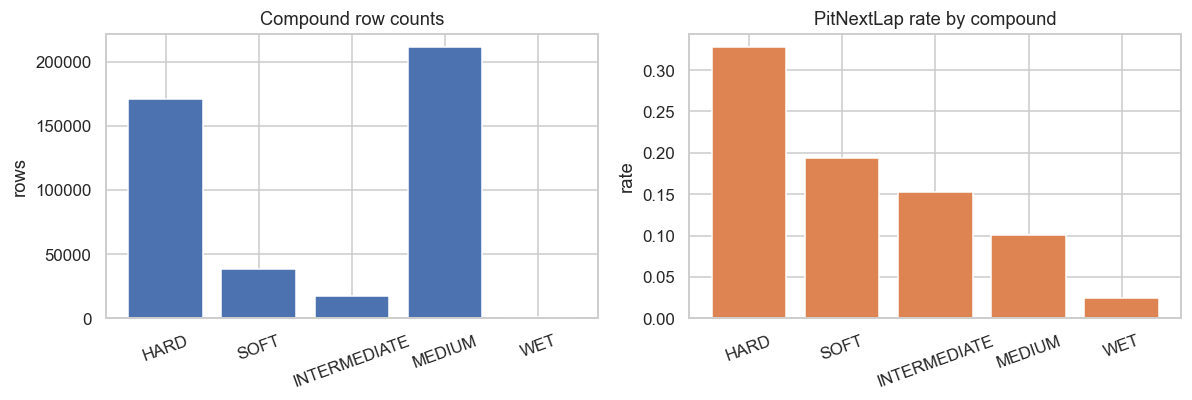

In [5]:
compound_stats = (
    train.group_by("Compound")
    .agg(pl.len().alias("n_rows"), pl.col("PitNextLap").mean().alias("rate"))
    .sort("rate", descending=True)
)
labels = compound_stats["Compound"].to_list()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(labels, compound_stats["n_rows"].to_list(), color="#4c72b0")
axes[0].set_title("Compound row counts")
axes[0].set_ylabel("rows")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(labels, compound_stats["rate"].to_list(), color="#dd8452")
axes[1].set_title("PitNextLap rate by compound")
axes[1].set_ylabel("rate")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 4. Race row counts

26 races, identical set in train and test (incl. `Pre-Season Testing`).

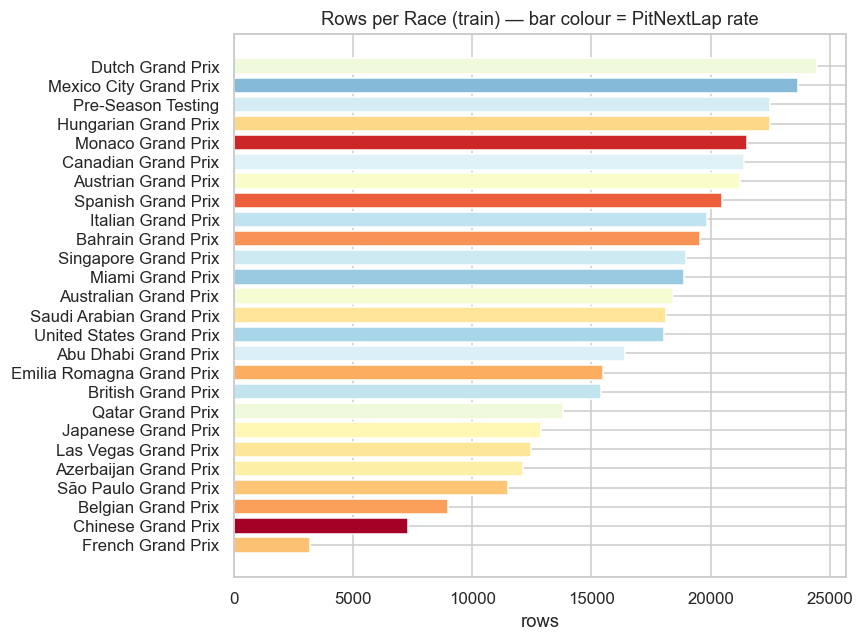

In [6]:
race_stats = (
    train.group_by("Race")
    .agg(pl.len().alias("n_rows"), pl.col("PitNextLap").mean().alias("rate"))
    .sort("n_rows")
)

fig, ax = plt.subplots(figsize=(8, 6))
race_names = race_stats["Race"].to_list()
n_rows = race_stats["n_rows"].to_list()
rates = race_stats["rate"].to_list()
colors = plt.cm.RdYlBu_r(np.array(rates) / max(rates))
ax.barh(race_names, n_rows, color=colors)
ax.set_title("Rows per Race (train) — bar colour = PitNextLap rate")
ax.set_xlabel("rows")
plt.tight_layout()
plt.show()

## 5. Numeric distributions & outliers

`LapTime`, `LapTime_Delta` and `Cumulative_Degradation` carry extreme tails (safety-car / red-flag laps). Histograms below are clipped to 1–99% so the bulk shape is visible — keep in mind the actual maxima are ~2400.

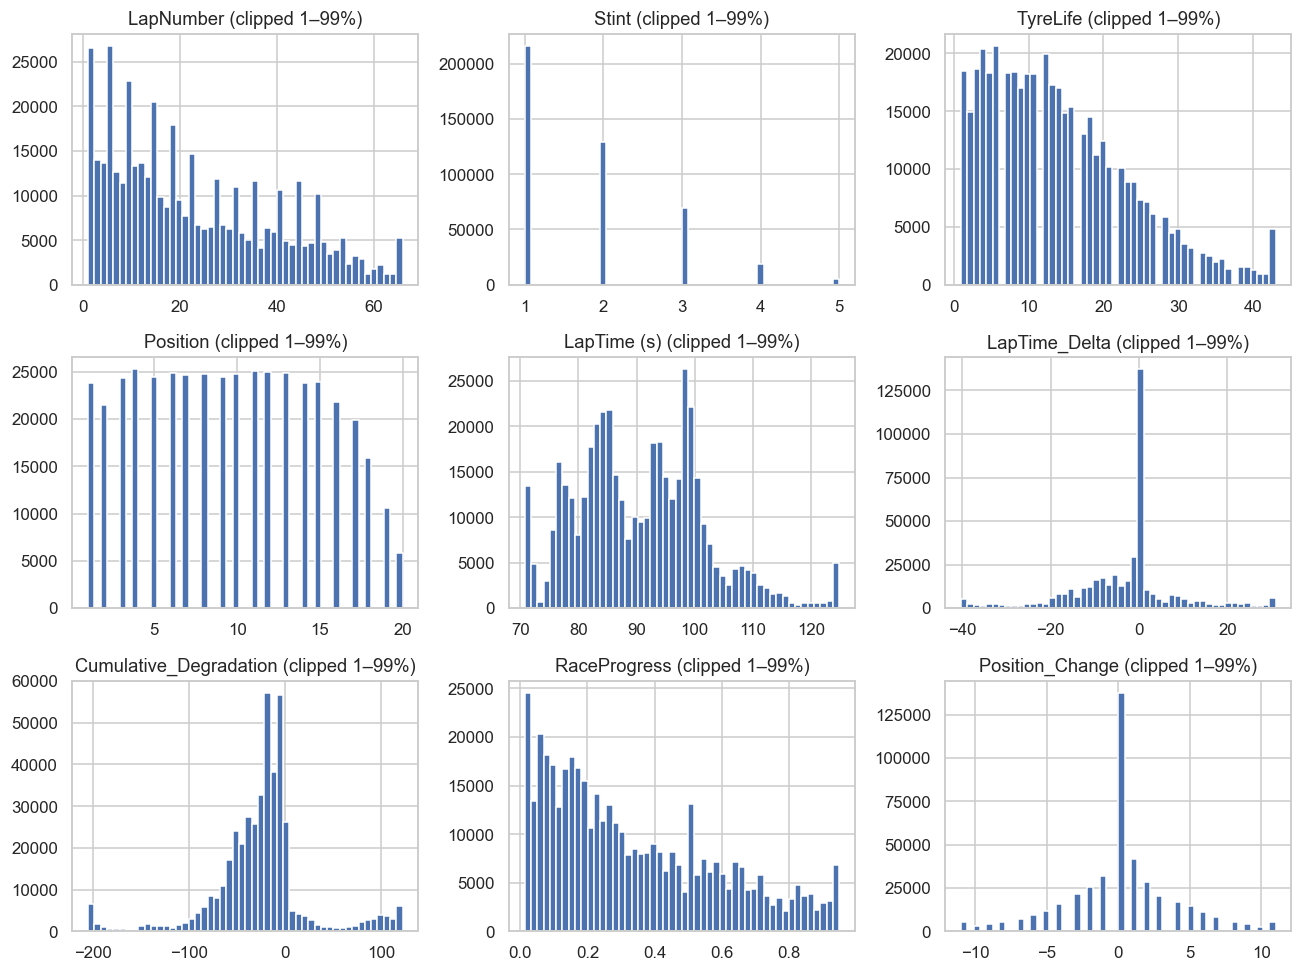

In [7]:
plot_cols = [
    "LapNumber", "Stint", "TyreLife", "Position",
    "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation",
    "RaceProgress", "Position_Change",
]
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, col in zip(axes.ravel(), plot_cols):
    series = train[col].to_numpy()
    p1, p99 = np.quantile(series, [0.01, 0.99])
    ax.hist(np.clip(series, p1, p99), bins=50, color="#4c72b0")
    ax.set_title(f"{col} (clipped 1–99%)")
plt.tight_layout()
plt.show()

## 6. Train vs test overlap

The split is row-level random, so train and test should have near-identical marginals on every column.

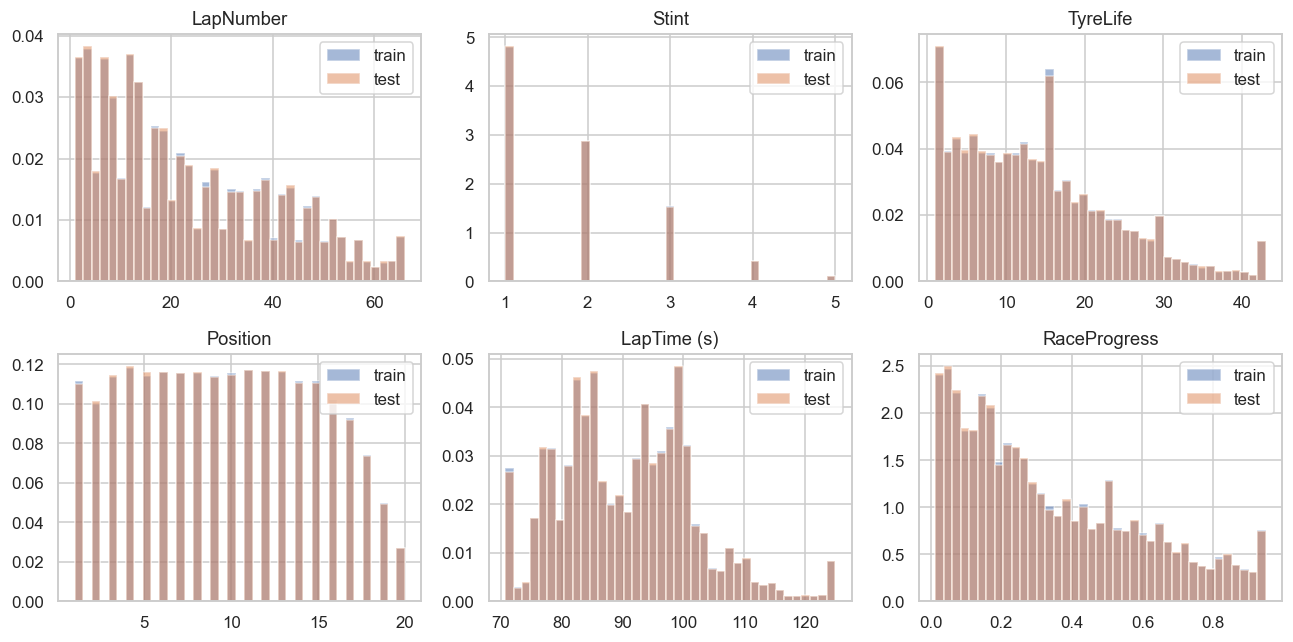

In [8]:
compare_cols = ["LapNumber", "Stint", "TyreLife", "Position", "LapTime (s)", "RaceProgress"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.ravel(), compare_cols):
    a = train[col].to_numpy()
    b = test[col].to_numpy()
    p1, p99 = np.quantile(np.concatenate([a, b]), [0.01, 0.99])
    bins = np.linspace(p1, p99, 40)
    ax.hist(np.clip(a, p1, p99), bins=bins, alpha=0.5, label="train", density=True, color="#4c72b0")
    ax.hist(np.clip(b, p1, p99), bins=bins, alpha=0.5, label="test", density=True, color="#dd8452")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Correlation heatmap

`LapNumber ↔ RaceProgress` is 0.97 (near-redundant). `TyreLife`, `LapNumber`, `Stint` carry the strongest target signal.

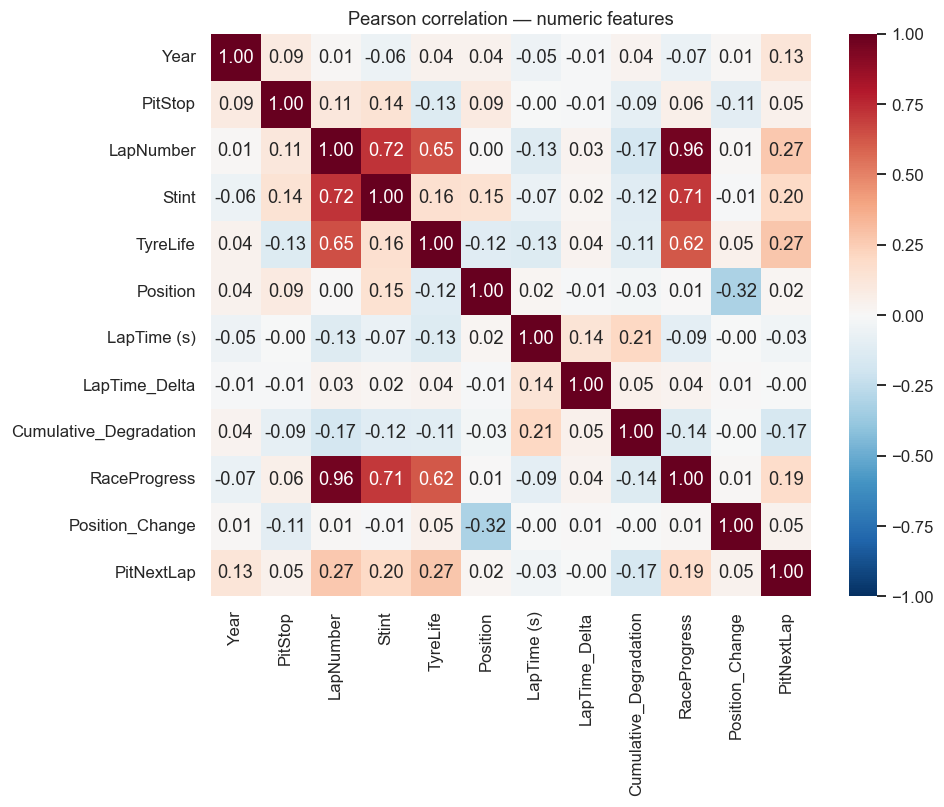

In [9]:
num_cols = [
    c for c, d in zip(train.columns, train.dtypes)
    if d.is_numeric() and c != "id"
]
n = len(num_cols)
corr = np.zeros((n, n))
for i, a in enumerate(num_cols):
    for j, b in enumerate(num_cols):
        corr[i, j] = train.select(pl.corr(a, b)).item()

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(
    corr, xticklabels=num_cols, yticklabels=num_cols,
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax,
)
ax.set_title("Pearson correlation — numeric features")
plt.tight_layout()
plt.show()

## 8. TyreLife (× Compound)

`TyreLife` is the dominant single feature. The `Compound × TyreLife` interaction is strong: HARD tolerates 50+ laps, SOFT plateaus around 24% by mid-stint.

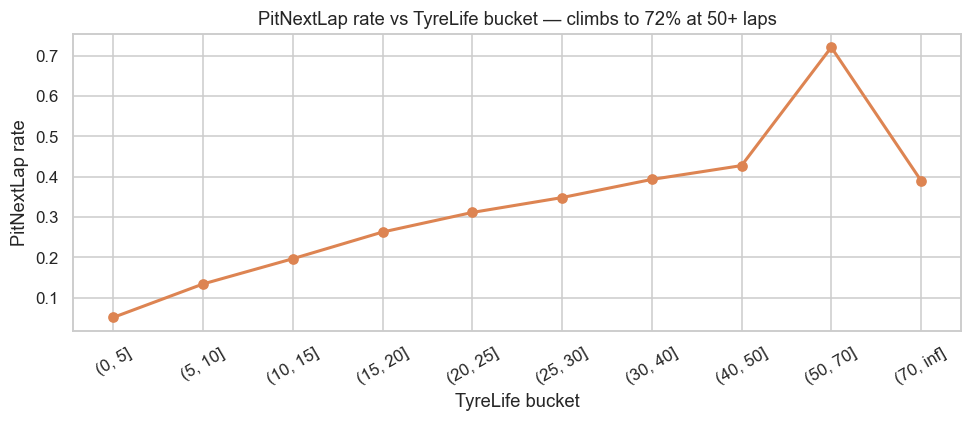

In [10]:
tl = (
    train.with_columns(
        pl.col("TyreLife").cut([0, 5, 10, 15, 20, 25, 30, 40, 50, 70]).alias("life_bucket")
    )
    .group_by("life_bucket")
    .agg(pl.col("PitNextLap").mean().alias("rate"), pl.len().alias("n"))
    .sort("life_bucket")
)

fig, ax = plt.subplots(figsize=(9, 4))
labels = [str(x) for x in tl["life_bucket"].to_list()]
ax.plot(labels, tl["rate"].to_list(), marker="o", color="#dd8452", linewidth=2)
ax.set_title("PitNextLap rate vs TyreLife bucket — climbs to 72% at 50+ laps")
ax.set_xlabel("TyreLife bucket")
ax.set_ylabel("PitNextLap rate")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

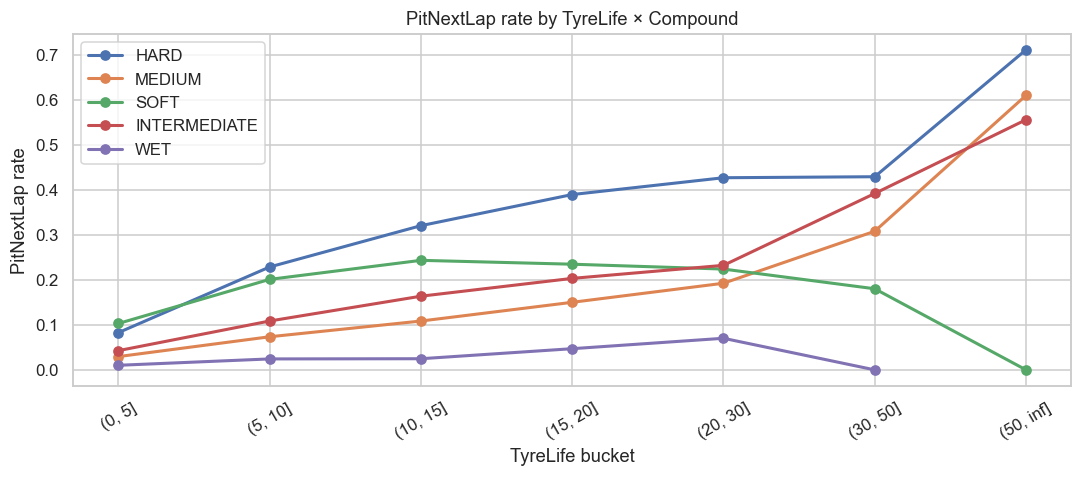

In [11]:
tc = (
    train.with_columns(
        pl.col("TyreLife").cut([0, 5, 10, 15, 20, 30, 50]).alias("life_bucket")
    )
    .group_by(["Compound", "life_bucket"])
    .agg(pl.col("PitNextLap").mean().alias("rate"), pl.len().alias("n"))
    .sort(["Compound", "life_bucket"])
)

fig, ax = plt.subplots(figsize=(10, 4.5))
for comp in ["HARD", "MEDIUM", "SOFT", "INTERMEDIATE", "WET"]:
    sub_df = tc.filter(pl.col("Compound") == comp)
    if sub_df.height == 0:
        continue
    ax.plot(
        [str(x) for x in sub_df["life_bucket"].to_list()],
        sub_df["rate"].to_list(),
        marker="o", label=comp, linewidth=2,
    )
ax.set_title("PitNextLap rate by TyreLife × Compound")
ax.set_xlabel("TyreLife bucket")
ax.set_ylabel("PitNextLap rate")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

## 9. RaceProgress pit window

Classic mid-race pit window: <10% pit rate at race start and end, peak ~39% in the 50–70% window.

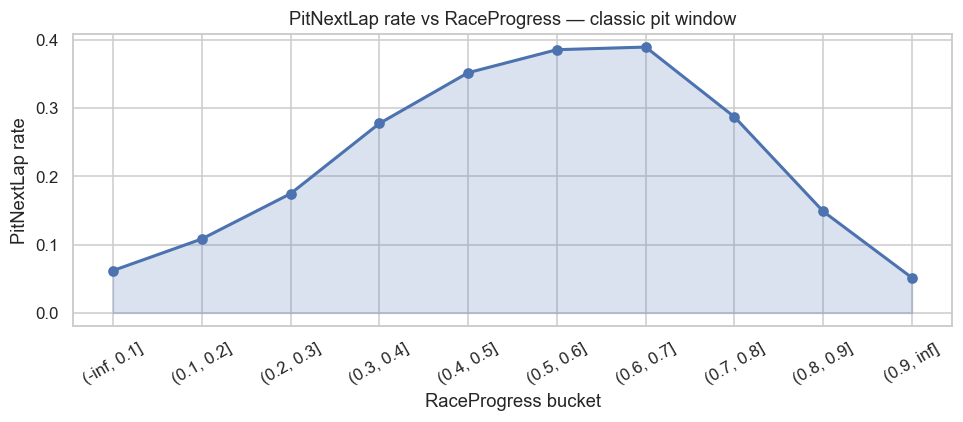

In [12]:
rp = (
    train.with_columns(
        pl.col("RaceProgress").cut([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]).alias("rp_bucket")
    )
    .group_by("rp_bucket")
    .agg(pl.col("PitNextLap").mean().alias("rate"), pl.len().alias("n"))
    .sort("rp_bucket")
)

fig, ax = plt.subplots(figsize=(9, 4))
labels = [str(x) for x in rp["rp_bucket"].to_list()]
ax.plot(labels, rp["rate"].to_list(), marker="o", color="#4c72b0", linewidth=2)
ax.fill_between(labels, rp["rate"].to_list(), alpha=0.2, color="#4c72b0")
ax.set_title("PitNextLap rate vs RaceProgress — classic pit window")
ax.set_xlabel("RaceProgress bucket")
ax.set_ylabel("PitNextLap rate")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 10. Position → target rate

Flat — pit decisions are tyre/strategy-driven, not position-driven.

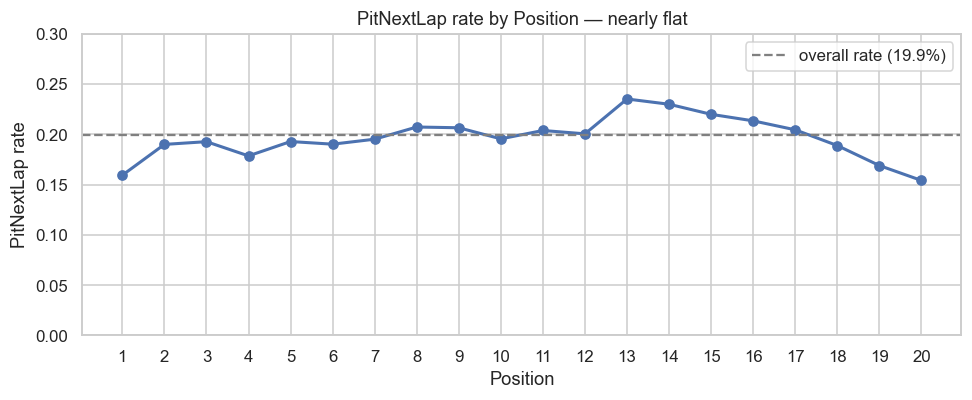

In [13]:
pos_stats = (
    train.group_by("Position")
    .agg(pl.col("PitNextLap").mean().alias("rate"), pl.len().alias("n"))
    .sort("Position")
)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(pos_stats["Position"].to_list(), pos_stats["rate"].to_list(),
        marker="o", color="#4c72b0", linewidth=2)
ax.axhline(0.199, color="grey", linestyle="--", label="overall rate (19.9%)")
ax.set_title("PitNextLap rate by Position — nearly flat")
ax.set_xlabel("Position")
ax.set_ylabel("PitNextLap rate")
ax.set_xticks(pos_stats["Position"].to_list())
ax.set_ylim(0, 0.30)
ax.legend()
plt.tight_layout()
plt.show()

## 11. Engineered features

Plots below load `data/train_features.parquet` (run `python src/features.py` to generate). See [docs/feature_engineering.md](../docs/feature_engineering.md) for the full feature catalog.

### 11.1 Field pit share — the strongest engineered signal

When several cars pit on lap N, the rest of the field reacts on lap N+1. The leave-one-out `field_pit_share` per `(Race, Year, LapNumber)` captures this directly. Quintile target rate climbs **2.2% → 38.2%** — the largest spread of any feature in the catalog.

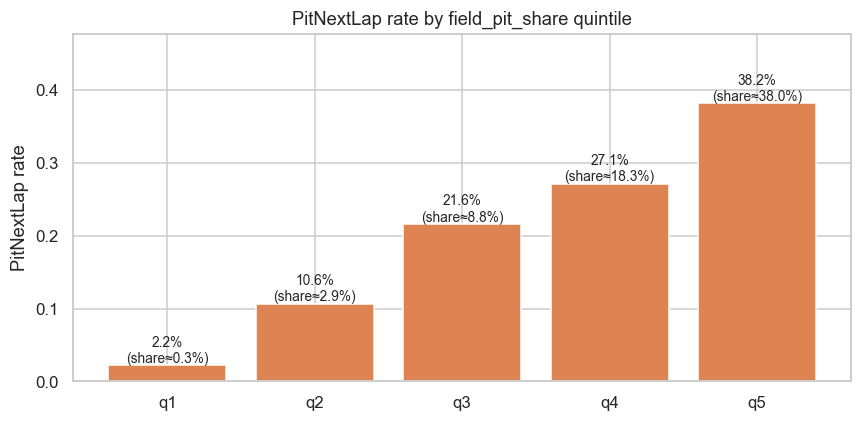

In [14]:
if train_fe is None:
    print("train_features.parquet not found — skipping engineered-feature plots")
else:
    fps = (
        train_fe.with_columns(
            pl.col("field_pit_share")
            .qcut(5, labels=["q1", "q2", "q3", "q4", "q5"])
            .alias("bucket")
        )
        .group_by("bucket")
        .agg(
            pl.col("PitNextLap").mean().alias("rate"),
            pl.col("field_pit_share").mean().alias("share_mean"),
            pl.len().alias("n"),
        )
        .sort("share_mean")
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(fps["bucket"].to_list(), fps["rate"].to_list(), color="#dd8452")
    for i, (r, m) in enumerate(zip(fps["rate"].to_list(), fps["share_mean"].to_list())):
        ax.text(i, r, f"{r:.1%}\n(share≈{m:.1%})", ha="center", va="bottom", fontsize=9)
    ax.set_title("PitNextLap rate by field_pit_share quintile")
    ax.set_ylabel("PitNextLap rate")
    ax.set_ylim(0, max(fps["rate"].to_list()) * 1.25)
    plt.tight_layout()
    plt.show()

### 11.2 Safety-car detection (`sc_likely`)

Field-wide lap-time spike detector: `field_median_laptime / clean_baseline > 1.15`. Monaco tops the per-race ranking — matches the real-world circuit's reputation for SCs.

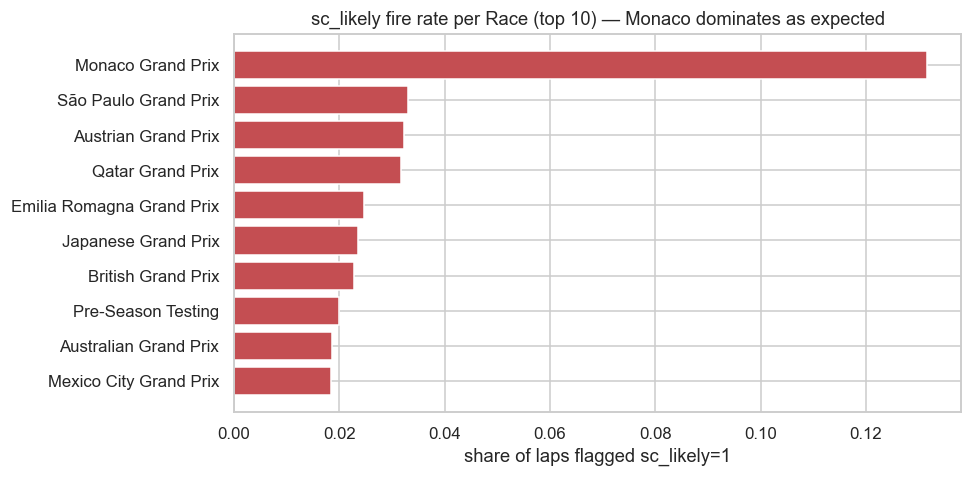

In [15]:
if train_fe is not None:
    sc_share = (
        train_fe.group_by("Race")
        .agg(pl.col("sc_likely").mean().alias("sc_share"))
        .sort("sc_share", descending=True)
        .head(10)
    )

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.barh(
        sc_share["Race"].to_list()[::-1],
        sc_share["sc_share"].to_list()[::-1],
        color="#c44e52",
    )
    ax.set_title("sc_likely fire rate per Race (top 10) — Monaco dominates as expected")
    ax.set_xlabel("share of laps flagged sc_likely=1")
    plt.tight_layout()
    plt.show()

### 11.3 Undercut / overcut signals

Pit-stop activity at the Position immediately ahead/behind in the same lap. The 2×2 contingency captures the canonical undercut trigger: when both neighbours pit recently, this driver's pit-next probability is **3.4× higher** than when neither does.

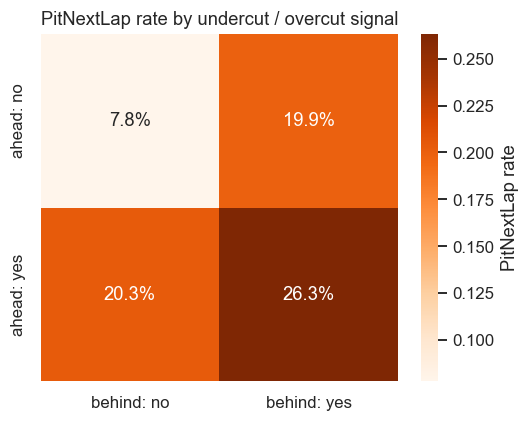

In [16]:
if train_fe is not None:
    grid = (
        train_fe.group_by(
            (pl.col("ahead_pitted_last_3").fill_null(0) > 0)
            .cast(pl.Int8)
            .alias("ahead"),
            (pl.col("behind_pitted_last_3").fill_null(0) > 0)
            .cast(pl.Int8)
            .alias("behind"),
        )
        .agg(pl.col("PitNextLap").mean().alias("rate"), pl.len().alias("n"))
        .sort("ahead", "behind")
    )

    mat = np.zeros((2, 2))
    for row in grid.iter_rows(named=True):
        mat[row["ahead"], row["behind"]] = row["rate"]

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        mat, annot=True, fmt=".1%", cmap="Oranges",
        xticklabels=["behind: no", "behind: yes"],
        yticklabels=["ahead: no", "ahead: yes"],
        cbar_kws={"label": "PitNextLap rate"}, ax=ax,
    )
    ax.set_title("PitNextLap rate by undercut / overcut signal")
    plt.tight_layout()
    plt.show()

### 11.4 Normalized TyreLife

`tyre_life_norm = TyreLife / typical_stint_length(Compound, Race)` collapses the `Compound × TyreLife` interaction into one axis. Quintile target rate climbs 3.5% → 35.9%.

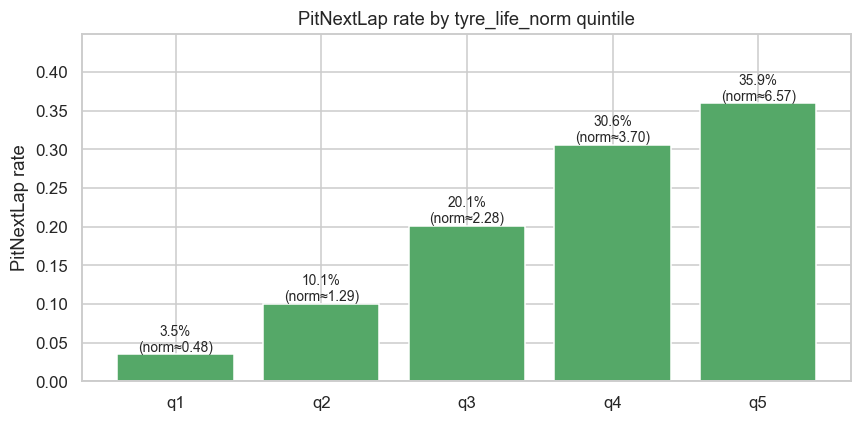

In [17]:
if train_fe is not None:
    tn = (
        train_fe.with_columns(
            pl.col("tyre_life_norm")
            .qcut(5, labels=["q1", "q2", "q3", "q4", "q5"], allow_duplicates=True)
            .alias("bucket")
        )
        .filter(pl.col("bucket").is_not_null())
        .group_by("bucket")
        .agg(
            pl.col("PitNextLap").mean().alias("rate"),
            pl.col("tyre_life_norm").mean().alias("norm_mean"),
            pl.len().alias("n"),
        )
        .sort("norm_mean")
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(tn["bucket"].to_list(), tn["rate"].to_list(), color="#55a868")
    for i, (r, m) in enumerate(zip(tn["rate"].to_list(), tn["norm_mean"].to_list())):
        ax.text(i, r, f"{r:.1%}\n(norm≈{m:.2f})", ha="center", va="bottom", fontsize=9)
    ax.set_title("PitNextLap rate by tyre_life_norm quintile")
    ax.set_ylabel("PitNextLap rate")
    ax.set_ylim(0, max(tn["rate"].to_list()) * 1.25)
    plt.tight_layout()
    plt.show()